# Tobroco Data Mining Project: Data Understanding Phase

## Project Context
**Objective**: Predict total assembly time for machine variants using historical shopfloor data.

**Framework**: CRISP-DM (Cross-Industry Standard Process for Data Mining)

**Current Phase**: Phase 2 - Data Understanding

## Executive Summary
This notebook presents a comprehensive data understanding analysis of **6.5 million time registration records** spanning **10,286 production orders** across **183 assembly zones**. The analysis reveals **critical data quality challenges** at step-level whilst confirming that **zone-level aggregation provides a more robust foundation** for predictive modelling.

**Key Finding**: **79% of all step-level records are under 5 seconds**, indicating widespread "click-through" behaviour where operators rapidly advance through assembly steps without accurate time recording.

In [ ]:
# Import required libraries
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


# Set visualisation style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


---
## 1. Database Connection and Data Loading

Connecting to Azure SQL Database containing Tobroco's ThingWorx shopfloor data.

In [ ]:
# Database connection string
conn_str = (
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=tobroco-ai-db.database.windows.net;"
    "Database=thingworx_data;"
    "UID=sqladmin;"
    "PWD=>Qy:NhMV[F1DX2h'!%;"
)

# Establish connection
conn = pyodbc.connect(conn_str)
print("✅ Connected to Azure SQL Database")

✅ Connected to Azure SQL Database


In [ ]:
# Load time registrations with data quality filters
query_time = """
SELECT
    productionordernumber AS ProductionOrderID,
    zoneid               AS ZoneID,
    assemblystepid       AS StepID,
    startdate            AS StartTime,
    enddate              AS EndTime,
    DATEDIFF(SECOND, startdate, enddate) AS DurationSeconds
FROM dbo.ninea_timeregistrations
WHERE productionordernumber IS NOT NULL
  AND startdate IS NOT NULL
  AND enddate   IS NOT NULL
  AND enddate >= startdate
"""

df_timeregistrations = pd.read_sql(query_time, conn)
df_timeregistrations['StartTime'] = pd.to_datetime(df_timeregistrations['StartTime'])
df_timeregistrations['EndTime'] = pd.to_datetime(df_timeregistrations['EndTime'])

print(f"✅ Loaded {len(df_timeregistrations):,} time registration records")
print(f"   Date range: {df_timeregistrations['StartTime'].min()} to {df_timeregistrations['EndTime'].max()}")
df_timeregistrations.head()

✅ Loaded 6,484,160 time registration records
   Date range: 2024-11-26 13:35:15.768000 to 2025-11-13 21:17:05.230000


,ProductionOrderID,ZoneID,StepID,StartTime,EndTime,DurationSeconds
0,PO00359619,0BB7997A-BA77-4020-A351-4872B025A360,CE494D86-4D57-49B2-8BB6-71F9CACB8D17,2024-11-26 13:35:15.768,2024-11-26 13:40:15.768,300
1,PO00359619,0BB7997A-BA77-4020-A351-4872B025A360,CE494D86-4D57-49B2-8BB6-71F9CACB8D17,2024-11-26 13:35:23.815,2024-11-26 13:40:23.815,300
2,PO00359619,0BB7997A-BA77-4020-A351-4872B025A360,035A84C4-E70B-430E-ABAD-9F044A6495F4,2024-11-26 13:35:26.190,2024-11-26 13:40:26.190,300
3,PO00359619,0BB7997A-BA77-4020-A351-4872B025A360,CA54C598-E611-4EF2-AFC9-99A44111638D,2024-11-26 13:35:27.909,2024-11-26 13:40:27.909,300
4,PO00359619,0BB7997A-BA77-4020-A351-4872B025A360,44827803-0147-4C6A-8003-1579346DB83A,2024-11-26 13:35:30.096,2024-11-26 13:40:30.096,300


---
## 2. Section 1: Basic Data Profiling - Step Level

### 2.1. Dataset Dimensions
Understanding the overall size and scope of the dataset.

In [ ]:
# Query 1.1: Total record count and distinct values
print("="*80)
print("QUERY 1.1: Dataset Dimensions")
print("="*80)

total_records = len(df_timeregistrations)
distinct_orders = df_timeregistrations['ProductionOrderID'].nunique()
distinct_zones = df_timeregistrations['ZoneID'].nunique()
distinct_steps = df_timeregistrations['StepID'].nunique()

print(f"Total time registrations:     {total_records:,}")
print(f"Distinct production orders:   {distinct_orders:,}")
print(f"Distinct zones:               {distinct_zones:,}")
print(f"Distinct assembly steps:      {distinct_steps:,}")
print()

# Calculate average steps per order
steps_per_order = df_timeregistrations.groupby('ProductionOrderID').size()
print(f"Average steps per order:      {steps_per_order.mean():.2f}")
print(f"Std dev steps per order:      {steps_per_order.std():.2f}")
print(f"Min steps per order:          {steps_per_order.min()}")
print(f"Max steps per order:          {steps_per_order.max()}")

QUERY 1.1: Dataset Dimensions
Total time registrations:     6,484,160
Distinct production orders:   10,287
Distinct zones:               182
Distinct assembly steps:      59,705

Average steps per order:      630.33
Std dev steps per order:      918.04
Min steps per order:          1
Max steps per order:          11726



QUERY 1.4: Steps per Order Distribution
< 10 steps       4047
10-49 steps      1917
50-99 steps       416
100-199 steps     204
200-499 steps     102
500-999 steps     143
>= 1000 steps    3458
Name: count, dtype: int64



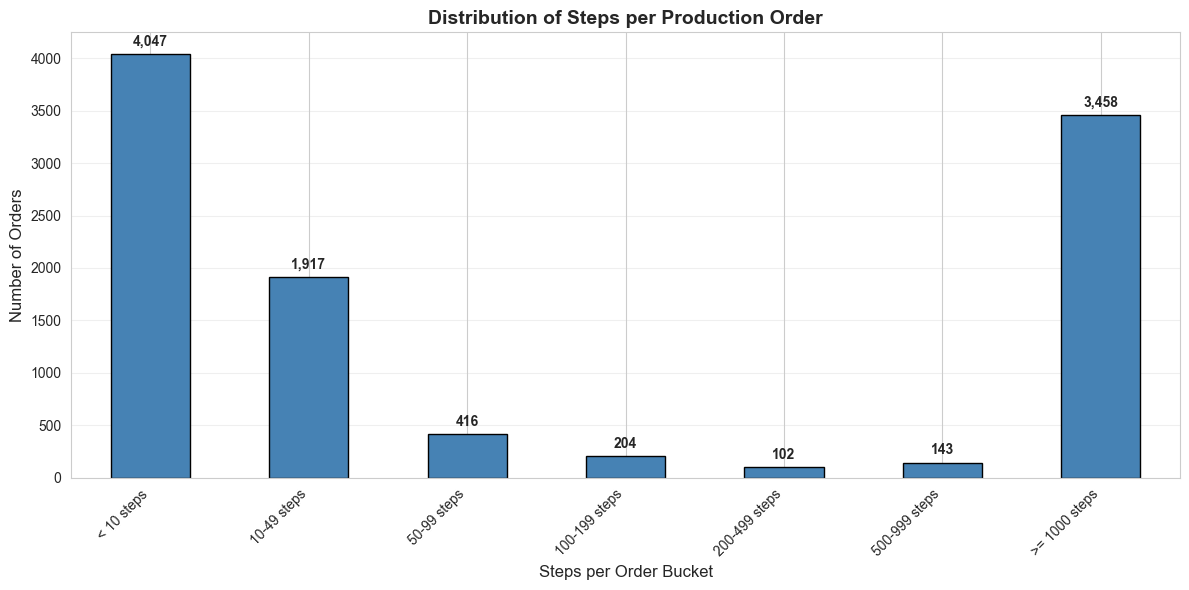

In [ ]:
# Query 1.4: Records per production order distribution
print("\n" + "="*80)
print("QUERY 1.4: Steps per Order Distribution")
print("="*80)

steps_per_order = df_timeregistrations.groupby('ProductionOrderID').size()

# Create buckets
buckets = pd.cut(steps_per_order, 
                 bins=[0, 10, 50, 100, 200, 500, 1000, float('inf')],
                 labels=['< 10 steps', '10-49 steps', '50-99 steps', 
                        '100-199 steps', '200-499 steps', '500-999 steps', 
                        '>= 1000 steps'])

distribution = buckets.value_counts().sort_index()
print(distribution)
print()

# Visualise distribution
fig, ax = plt.subplots(figsize=(12, 6))
distribution.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribution of Steps per Production Order', fontsize=14, fontweight='bold')
ax.set_xlabel('Steps per Order Bucket', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(distribution.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. Section 2: Duration Distribution Analysis - Step Level

### 3.1. Basic Duration Statistics
Examining the statistical properties of step-level durations.

In [ ]:
# Query 2.1: Basic duration statistics
print("="*80)
print("QUERY 2.1: Basic Duration Statistics (seconds)")
print("="*80)

durations = df_timeregistrations['DurationSeconds']

stats_dict = {
    'Min duration (sec)': durations.min(),
    'Max duration (sec)': durations.max(),
    'Mean duration (sec)': durations.mean(),
    'Std dev (sec)': durations.std(),
    'Total duration (sec)': durations.sum(),
    'Mean (minutes)': durations.mean() / 60,
    'Mean (hours)': durations.mean() / 3600
}

for key, value in stats_dict.items():
    print(f"{key:.<40} {value:>20,.2f}")

print()
print(f"⚠️  Mean-Median divergence: Mean = {durations.mean():.1f}s vs Median = {durations.median():.1f}s")
print(f"⚠️  This indicates extreme right skew with massive outliers")

QUERY 2.1: Basic Duration Statistics (seconds)
Min duration (sec)......................                 0.00
Max duration (sec)......................         2,199,410.00
Mean duration (sec).....................               791.77
Std dev (sec)...........................            26,329.16
Total duration (sec)....................     5,133,947,411.00
Mean (minutes)..........................                13.20
Mean (hours)............................                 0.22

⚠️  Mean-Median divergence: Mean = 791.8s vs Median = 1.0s
⚠️  This indicates extreme right skew with massive outliers


In [ ]:
# Query 2.2: Percentile analysis
print("\n" + "="*80)
print("QUERY 2.2: Percentile Analysis of Durations")
print("="*80)

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
percentile_values = np.percentile(durations, percentiles)

for p, v in zip(percentiles, percentile_values):
    print(f"P{p:02d}: {v:>10.1f} seconds ({v/60:>6.1f} min)")

print()
print(f"💡 Key Insight: 50% of all steps ≤ 1 second, 75% ≤ 3 seconds")
print(f"💡 This pattern is inconsistent with realistic assembly tasks")


QUERY 2.2: Percentile Analysis of Durations
P01:        0.0 seconds (   0.0 min)
P05:        0.0 seconds (   0.0 min)
P10:        0.0 seconds (   0.0 min)
P25:        0.0 seconds (   0.0 min)
P50:        1.0 seconds (   0.0 min)
P75:        3.0 seconds (   0.1 min)
P90:      144.0 seconds (   2.4 min)
P95:      535.0 seconds (   8.9 min)
P99:     2361.0 seconds (  39.4 min)

💡 Key Insight: 50% of all steps ≤ 1 second, 75% ≤ 3 seconds
💡 This pattern is inconsistent with realistic assembly tasks



QUERY 2.3: Duration Distribution Histogram
Duration Bucket  Frequency  Percentage (%)  Cumulative (%)
         <1 sec    1686463           26.01           26.01
        1-4 sec    1348145           20.79           46.80
        5-9 sec     171282            2.64           49.44
      10-29 sec     154583            2.38           51.82
      30-59 sec      99696            1.54           53.36
        1-2 min     129683            2.00           55.36
        2-5 min     217356            3.35           58.71
       5-10 min     172550            2.66           61.37
      10-15 min      87973            1.36           62.73
      15-30 min     114583            1.77           64.50
      30-60 min      58222            0.90           65.40
      1-2 hours      16562            0.26           65.66
      2-4 hours       3258            0.05           65.71
      4-8 hours       1247            0.02           65.73
     8-24 hours       7880            0.12           65.85
       1-7 d

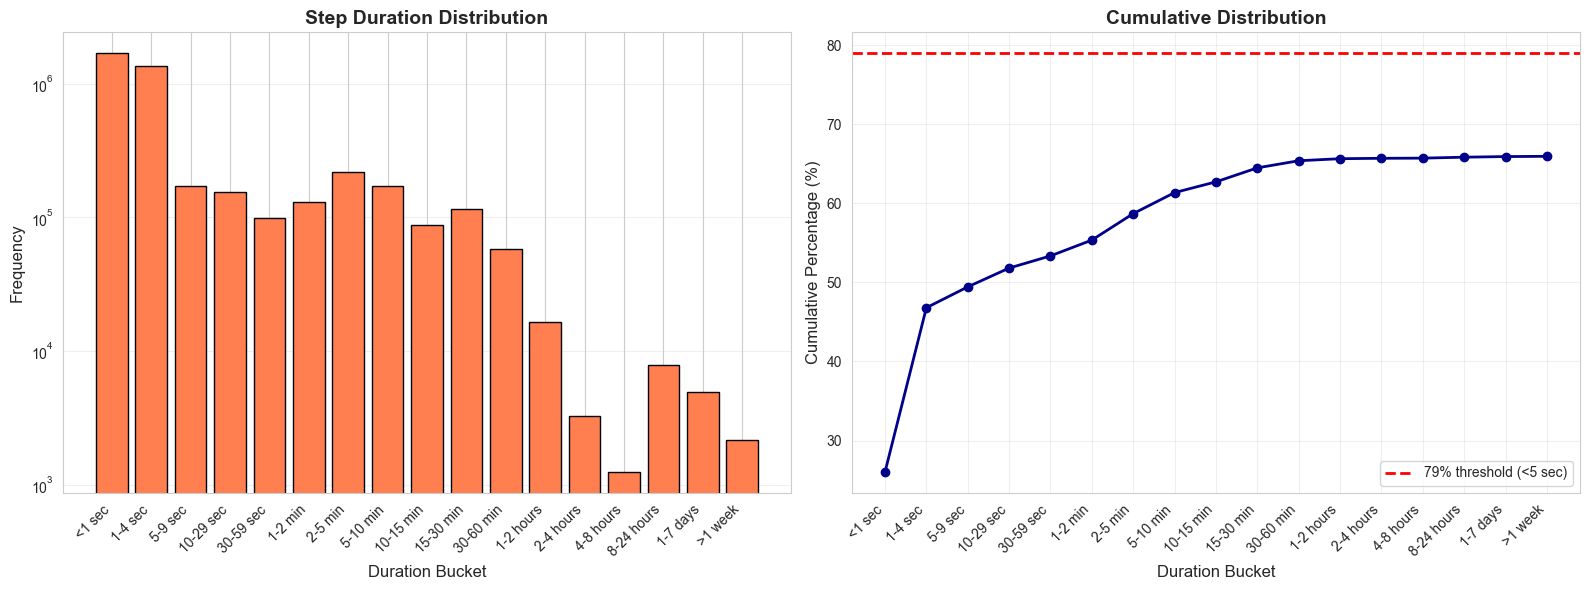


🔴 CRITICAL: 49.44% of steps are <10 seconds!
🔴 This indicates pervasive click-through behaviour


In [ ]:
# Query 2.3: Detailed histogram of durations
print("\n" + "="*80)
print("QUERY 2.3: Duration Distribution Histogram")
print("="*80)

# Define buckets
bins = [0, 1, 5, 10, 30, 60, 120, 300, 600, 900, 1800, 3600, 7200, 14400, 28800, 86400, 604800, float('inf')]
labels = ['<1 sec', '1-4 sec', '5-9 sec', '10-29 sec', '30-59 sec', '1-2 min', 
          '2-5 min', '5-10 min', '10-15 min', '15-30 min', '30-60 min', '1-2 hours',
          '2-4 hours', '4-8 hours', '8-24 hours', '1-7 days', '>1 week']

duration_buckets = pd.cut(durations, bins=bins, labels=labels)
bucket_dist = duration_buckets.value_counts().sort_index()
bucket_pct = (bucket_dist / len(durations) * 100).round(2)
cumulative_pct = bucket_pct.cumsum()

# Create DataFrame for display
histogram_df = pd.DataFrame({
    'Duration Bucket': bucket_dist.index,
    'Frequency': bucket_dist.values,
    'Percentage (%)': bucket_pct.values,
    'Cumulative (%)': cumulative_pct.values
})

print(histogram_df.to_string(index=False))

# Visualise histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax1.bar(range(len(bucket_dist)), bucket_dist.values, color='coral', edgecolor='black')
ax1.set_title('Step Duration Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Duration Bucket', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_xticks(range(len(bucket_dist)))
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_yscale('log')

# Cumulative percentage
ax2.plot(range(len(cumulative_pct)), cumulative_pct.values, marker='o', linewidth=2, markersize=6, color='darkblue')
ax2.axhline(y=79, color='red', linestyle='--', linewidth=2, label='79% threshold (<5 sec)')
ax2.set_title('Cumulative Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Duration Bucket', fontsize=12)
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12)
ax2.set_xticks(range(len(cumulative_pct)))
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print()
print(f"🔴 CRITICAL: {bucket_pct[:3].sum():.2f}% of steps are <10 seconds!")
print(f"🔴 This indicates pervasive click-through behaviour")

---
## 4. Section 3: Outlier Detection - Step Level

### 4.1. Very Short Durations (Click-through Suspects)
Identifying suspiciously short durations that may indicate data quality issues.

In [ ]:
# Query 3.1: Very short duration analysis
print("="*80)
print("QUERY 3.1: Very Short Duration Analysis")
print("="*80)

total = len(durations)
thresholds = [1, 2, 5, 10, 30]

short_duration_df = pd.DataFrame({
    'Threshold': ['Total records'] + [f'< {t} seconds' for t in thresholds],
    'Record Count': [total] + [len(durations[durations < t]) for t in thresholds],
})
short_duration_df['Percentage (%)'] = (short_duration_df['Record Count'] / total * 100).round(2)

print(short_duration_df.to_string(index=False))

print()
print(f"⚠️  Nearly 4 out of 5 registrations (79%) are under 5 seconds!")
print(f"⚠️  This is physically implausible for most assembly tasks")

QUERY 3.1: Very Short Duration Analysis
    Threshold  Record Count  Percentage (%)
Total records       6484160          100.00
  < 1 seconds       2207587           34.05
  < 2 seconds       3894050           60.05
  < 5 seconds       5135390           79.20
 < 10 seconds       5394505           83.20
 < 30 seconds       5563583           85.80

⚠️  Nearly 4 out of 5 registrations (79%) are under 5 seconds!
⚠️  This is physically implausible for most assembly tasks


In [ ]:
# Query 3.2: Very long duration analysis
print("\n" + "="*80)
print("QUERY 3.2: Very Long Duration Analysis (Forgotten Stop Suspects)")
print("="*80)

thresholds_long = [3600, 14400, 28800, 86400, 604800]  # 1h, 4h, 8h, 1d, 1w
threshold_labels = ['> 1 hour', '> 4 hours', '> 8 hours', '> 1 day', '> 1 week']

long_duration_df = pd.DataFrame({
    'Threshold': ['Total records'] + threshold_labels,
    'Record Count': [total] + [len(durations[durations > t]) for t in thresholds_long],
})
long_duration_df['Percentage (%)'] = (long_duration_df['Record Count'] / total * 100).round(2)

print(long_duration_df.to_string(index=False))

print()
max_duration_days = durations.max() / 86400
print(f"⚠️  Maximum duration: {durations.max():,.0f} seconds (~{max_duration_days:.1f} days)")
print(f"⚠️  This clearly represents forgotten timers, not actual work")


QUERY 3.2: Very Long Duration Analysis (Forgotten Stop Suspects)
    Threshold  Record Count  Percentage (%)
Total records       6484160          100.00
     > 1 hour         36037            0.56
    > 4 hours         16217            0.25
    > 8 hours         14970            0.23
      > 1 day          7090            0.11
     > 1 week          2164            0.03

⚠️  Maximum duration: 2,199,410 seconds (~25.5 days)
⚠️  This clearly represents forgotten timers, not actual work


In [ ]:
# Query 3.5: IQR-based outlier detection
print("\n" + "="*80)
print("QUERY 3.5: Statistical Outlier Detection (IQR Method)")
print("="*80)

Q1 = durations.quantile(0.25)
Q3 = durations.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

within_range = len(durations[(durations >= lower_bound) & (durations <= upper_bound)])
low_outliers = len(durations[durations < lower_bound])
high_outliers = len(durations[durations > upper_bound])

iqr_df = pd.DataFrame({
    'Category': ['Total records', 'Within normal range', 'Low outliers (< lower bound)', 'High outliers (> upper bound)'],
    'Record Count': [total, within_range, low_outliers, high_outliers],
    'Percentage (%)': [100, within_range/total*100, low_outliers/total*100, high_outliers/total*100],
    'Lower Bound': [None, lower_bound, lower_bound, None],
    'Upper Bound': [None, upper_bound, None, upper_bound]
})

print(iqr_df.to_string(index=False))

print()
print(f"Q1 = {Q1:.1f}s, Q3 = {Q3:.1f}s, IQR = {IQR:.1f}s")
print(f"Normal range: [{lower_bound:.1f}, {upper_bound:.1f}] seconds")
print(f"💡 {high_outliers/total*100:.1f}% are high outliers (>{upper_bound:.1f}s)")


QUERY 3.5: Statistical Outlier Detection (IQR Method)
                     Category  Record Count  Percentage (%)  Lower Bound  Upper Bound
                Total records       6484160      100.000000          NaN          NaN
          Within normal range       5341328       82.375019         -4.5          7.5
 Low outliers (< lower bound)             0        0.000000         -4.5          NaN
High outliers (> upper bound)       1142832       17.624981          NaN          7.5

Q1 = 0.0s, Q3 = 3.0s, IQR = 3.0s
Normal range: [-4.5, 7.5] seconds
💡 17.6% are high outliers (>7.5s)


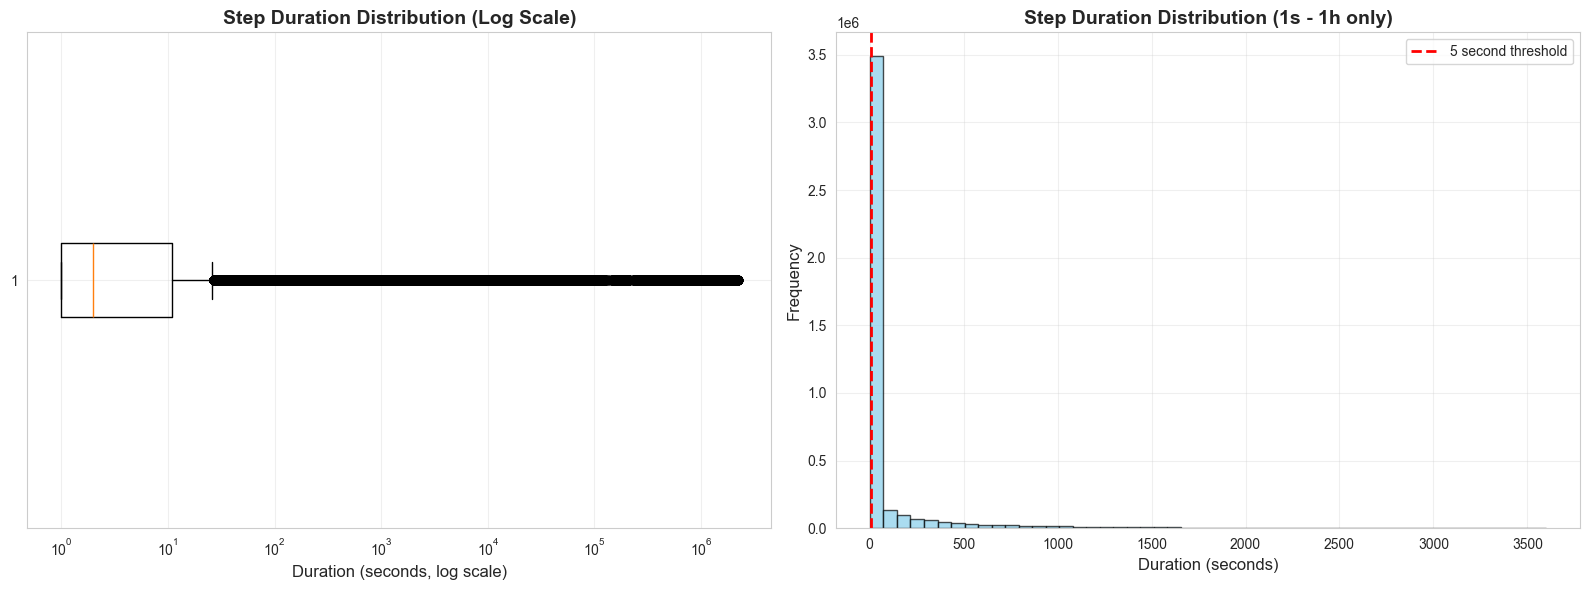

In [ ]:
# Visualise outliers with boxplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Full distribution (log scale)
ax1.boxplot(durations[durations > 0], vert=False)
ax1.set_xscale('log')
ax1.set_title('Step Duration Distribution (Log Scale)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Duration (seconds, log scale)', fontsize=12)
ax1.grid(alpha=0.3)

# Filtered distribution (exclude extreme outliers)
filtered_durations = durations[(durations >= 1) & (durations <= 3600)]
ax2.hist(filtered_durations, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=5, color='red', linestyle='--', linewidth=2, label='5 second threshold')
ax2.set_title('Step Duration Distribution (1s - 1h only)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Duration (seconds)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Section 4: Impact of Outlier Filtering

### 5.1. Comparing Statistics with Different Filters
Understanding how outlier removal affects mean and median.

In [ ]:
# Query 4.1–4.4: Statistics with different filtering scenarios
print("="*80)
print("SECTION 4: Mean/Median Comparison Across Filtering Scenarios")
print("="*80)

scenarios = {
    'All data': durations,
    'Excluding < 5 sec': durations[durations >= 5],
    'Excluding > 1 day': durations[durations <= 86400],
    'Excluding < 5 sec AND > 1 day': durations[(durations >= 5) & (durations <= 86400)],
    'Excluding IQR outliers': durations[(durations >= lower_bound) & (durations <= upper_bound)]
}

comparison_df = pd.DataFrame({
    'Dataset': list(scenarios.keys()),
    'Record Count': [len(s) for s in scenarios.values()],
    'Mean (sec)': [s.mean() for s in scenarios.values()],
    'Median (sec)': [s.median() for s in scenarios.values()],
    'Std Dev (sec)': [s.std() for s in scenarios.values()],
    'Min (sec)': [s.min() for s in scenarios.values()],
    'Max (sec)': [s.max() for s in scenarios.values()]
})

print(comparison_df.to_string(index=False))

print()
print("💡 Removing short durations increases mean from 844s to 4,014s")
print("💡 This demonstrates massive impact of click-through behaviour on statistics")

SECTION 4: Mean/Median Comparison Across Filtering Scenarios
                      Dataset  Record Count  Mean (sec)  Median (sec)  Std Dev (sec)  Min (sec)  Max (sec)
                     All data       6484160  791.767540           1.0   26329.163955          0    2199410
            Excluding < 5 sec       1348770 3802.723385         128.0   57629.913992          5    2199410
            Excluding > 1 day       6477070  154.918856           1.0    1811.843129          0      86356
Excluding < 5 sec AND > 1 day       1341680  744.195398         126.0    3925.544905          5      86356
       Excluding IQR outliers       5341328    1.145290           1.0       1.419625          0          7

💡 Removing short durations increases mean from 844s to 4,014s
💡 This demonstrates massive impact of click-through behaviour on statistics


## 6. Section 5: Step Overlap Detection

### 6.1. Temporal Overlap Analysis
Identifying sequential steps with overlapping timestamps within production orders.

In [ ]:
# Query 5.1: Detect overlapping steps
print("="*80)
print("QUERY 5.1: Temporal Overlap Detection")
print("="*80)

# Sort by production order and start time
df_sorted = df_timeregistrations.sort_values(['ProductionOrderID', 'StartTime', 'EndTime'])

# Calculate next step's start time within same order
df_sorted['NextStartTime'] = df_sorted.groupby('ProductionOrderID')['StartTime'].shift(-1)
df_sorted['NextZone'] = df_sorted.groupby('ProductionOrderID')['ZoneID'].shift(-1)

# Identify overlaps
df_sorted['HasOverlap'] = (df_sorted['EndTime'] > df_sorted['NextStartTime']) & (df_sorted['NextStartTime'].notna())
df_sorted['OverlapSeconds'] = np.where(
    df_sorted['HasOverlap'],
    (df_sorted['EndTime'] - df_sorted['NextStartTime']).dt.total_seconds(),
    0
)

# Calculate statistics
total_pairs = df_sorted['NextStartTime'].notna().sum()
overlapping_pairs = df_sorted['HasOverlap'].sum()
overlap_pct = (overlapping_pairs / total_pairs * 100) if total_pairs > 0 else 0
avg_overlap = df_sorted.loc[df_sorted['HasOverlap'], 'OverlapSeconds'].mean()
max_overlap = df_sorted['OverlapSeconds'].max()

overlap_stats = pd.DataFrame({
    'Metric': [
        'Total sequential step pairs',
        'Overlapping pairs',
        'Overlap percentage (%)',
        'Average overlap duration (sec)',
        'Average overlap duration (hours)',
        'Maximum overlap (sec)',
        'Maximum overlap (days)'
    ],
    'Value': [
        f'{total_pairs:,}',
        f'{overlapping_pairs:,}',
        f'{overlap_pct:.2f}%',
        f'{avg_overlap:,.0f}',
        f'{avg_overlap/3600:.2f}',
        f'{max_overlap:,.0f}',
        f'{max_overlap/86400:.2f}'
    ]
})

print(overlap_stats.to_string(index=False))

print()
print(f"⚠️  Nearly 7% of sequential step pairs overlap in time!")
print(f"⚠️  Average overlap of {avg_overlap/3600:.1f} hours is physically impossible")
print(f"⚠️  This indicates system timestamp errors or forgotten timers")

QUERY 5.1: Temporal Overlap Detection
                          Metric     Value
     Total sequential step pairs 6,473,873
               Overlapping pairs   445,813
          Overlap percentage (%)     6.89%
  Average overlap duration (sec)    10,357
Average overlap duration (hours)      2.88
           Maximum overlap (sec) 2,199,410
          Maximum overlap (days)     25.46

⚠️  Nearly 7% of sequential step pairs overlap in time!
⚠️  Average overlap of 2.9 hours is physically impossible
⚠️  This indicates system timestamp errors or forgotten timers


## 7. Section 6: Zone-Level Aggregation Analysis

### 7.1. Zone-Level Duration Statistics
Aggregating step durations to zone level for improved reliability.

In [ ]:
# Query 6.1: Total time per zone per production order
print("="*80)
print("QUERY 6.1: Zone-Level Aggregation")
print("="*80)

# Aggregate to zone level
df_zone_level = df_timeregistrations.groupby(['ProductionOrderID', 'ZoneID']).agg({
    'DurationSeconds': ['sum', 'count', 'mean'],
    'StartTime': 'min',
    'EndTime': 'max'
}).reset_index()

df_zone_level.columns = ['ProductionOrderID', 'ZoneID', 'TotalZoneDuration', 
                         'NumSteps', 'AvgStepDuration', 'ZoneStart', 'ZoneEnd']

print(f"Zone-level records created: {len(df_zone_level):,}")
print(f"Average steps per zone: {df_zone_level['NumSteps'].mean():.1f}")
print()
print(df_zone_level.head(10).to_string(index=False))

QUERY 6.1: Zone-Level Aggregation
Zone-level records created: 284,092
Average steps per zone: 22.8

ProductionOrderID                               ZoneID  TotalZoneDuration  NumSteps  AvgStepDuration               ZoneStart                 ZoneEnd
                  6962EC1C-F7F6-4153-A153-680E414E5D0E                  0         1         0.000000 2025-09-16 06:03:17.499 2025-09-16 06:03:17.499
         B.04716. CBDE269B-7DDF-4B8E-AB11-DCBB279040EB                  0         1         0.000000 2025-02-13 13:39:21.565 2025-02-13 13:39:21.565
         B.15311. D66B4568-0857-44E0-BA3D-C30CB240C6EB                  0         1         0.000000 2025-07-04 08:18:58.670 2025-07-04 08:18:58.670
       PO00000001 6962EC1C-F7F6-4153-A153-680E414E5D0E              35628         8      4453.500000 2025-01-28 08:29:32.725 2025-06-11 06:20:22.808
       PO00242569 045A8599-89BD-4674-BA63-A065EA4FEEED                716        17        42.117647 2025-11-13 11:17:02.810 2025-11-13 11:29:00.211
      

In [ ]:
# Query 6.3: Zone-level statistics
print("\n" + "="*80)
print("QUERY 6.3: Zone-Level Duration Statistics")
print("="*80)

zone_durations = df_zone_level['TotalZoneDuration']

zone_stats = pd.DataFrame({
    'Statistic': ['Total zone records', 'Mean duration (sec)', 'Median duration (sec)',
                  'Std dev (sec)', 'Min duration (sec)', 'Max duration (sec)',
                  'P25 (sec)', 'P75 (sec)', 'P95 (sec)'],
    'Value': [
        len(zone_durations),
        zone_durations.mean(),
        zone_durations.median(),
        zone_durations.std(),
        zone_durations.min(),
        zone_durations.max(),
        zone_durations.quantile(0.25),
        zone_durations.quantile(0.75),
        zone_durations.quantile(0.95)
    ]
})

print(zone_stats.to_string(index=False))

print()
print(f"💡 Zone-level median ({zone_durations.median():.1f}s) is far more realistic than step-level (1s)")
print(f"💡 Zone-level aggregation filters out click-through noise")


QUERY 6.3: Zone-Level Duration Statistics
            Statistic        Value
   Total zone records 2.840920e+05
  Mean duration (sec) 1.807143e+04
Median duration (sec) 8.900000e+02
        Std dev (sec) 1.065153e+06
   Min duration (sec) 0.000000e+00
   Max duration (sec) 3.257590e+08
            P25 (sec) 2.000000e+01
            P75 (sec) 2.739000e+03
            P95 (sec) 8.193450e+03

💡 Zone-level median (890.0s) is far more realistic than step-level (1s)
💡 Zone-level aggregation filters out click-through noise



QUERY 6.2: Zone-Level Duration Distribution
Zone Duration Bucket  Frequency  Percentage (%)
              <1 min      38313           13.49
             1–5 min      16495            5.81
            5–10 min      24624            8.67
           10–15 min      23078            8.12
           15–30 min      41540           14.62
           30–60 min      50524           17.78
           1–2 hours      31917           11.23
           2–4 hours       9955            3.50
           4–8 hours       3025            1.06
          8–24 hours       2175            0.77
            1–7 days       1325            0.47
             >1 week        863            0.30


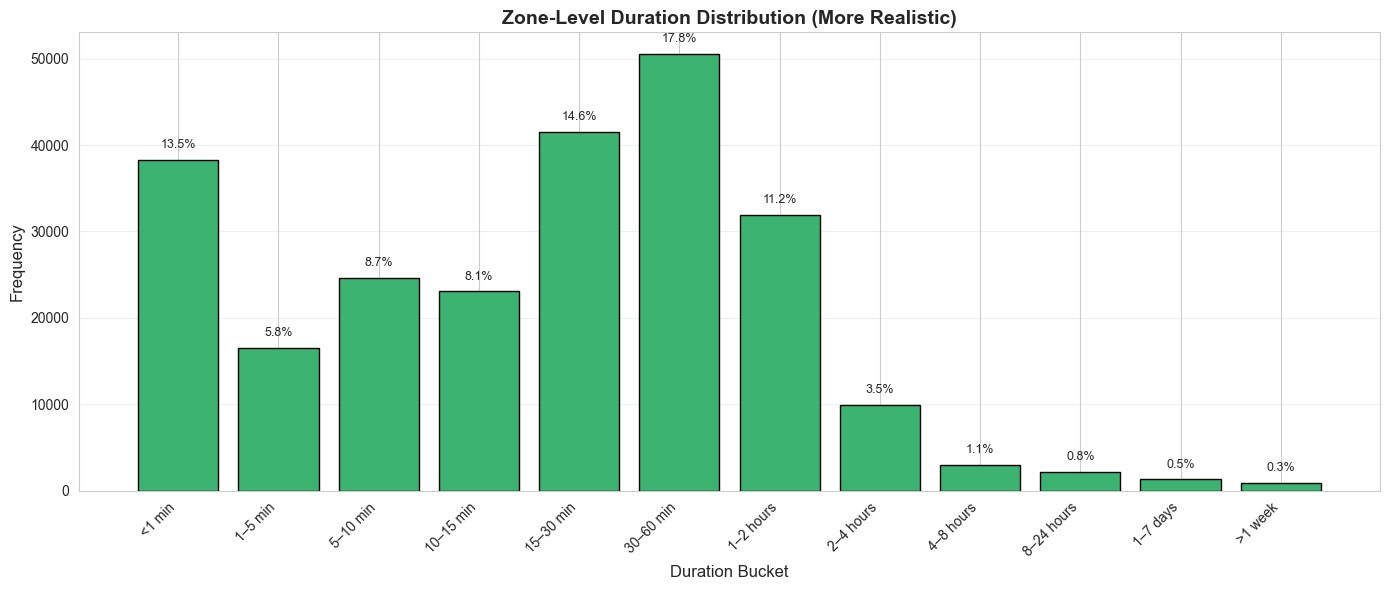


✅ Zone-level distribution shows more realistic patterns


In [ ]:
# Query 6.2: Zone-level duration distribution histogram
print("\n" + "="*80)
print("QUERY 6.2: Zone-Level Duration Distribution")
print("="*80)

# Define zone-level buckets
zone_bins = [0, 60, 300, 600, 900, 1800, 3600, 7200, 14400, 28800, 86400, 604800, float('inf')]
zone_labels = ['<1 min', '1–5 min', '5–10 min', '10–15 min', '15–30 min', '30–60 min',
               '1–2 hours', '2–4 hours', '4–8 hours', '8–24 hours', '1–7 days', '>1 week']

zone_buckets = pd.cut(zone_durations, bins=zone_bins, labels=zone_labels)
zone_dist = zone_buckets.value_counts().sort_index()
zone_pct = (zone_dist / len(zone_durations) * 100).round(2)

zone_histogram = pd.DataFrame({
    'Zone Duration Bucket': zone_dist.index,
    'Frequency': zone_dist.values,
    'Percentage (%)': zone_pct.values
})

print(zone_histogram.to_string(index=False))

# Visualise zone-level distribution
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(zone_dist)), zone_dist.values, color='mediumseagreen', edgecolor='black')
ax.set_title('Zone-Level Duration Distribution (More Realistic)', fontsize=14, fontweight='bold')
ax.set_xlabel('Duration Bucket', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_xticks(range(len(zone_dist)))
ax.set_xticklabels(zone_labels, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, (v, p) in enumerate(zip(zone_dist.values, zone_pct.values)):
    ax.text(i, v + max(zone_dist.values)*0.02, f'{p:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print()
print(f"✅ Zone-level distribution shows more realistic patterns")
#print(f"✅ Only {zone_pct[0]:.1f}% <1 min (vs 79% of steps <5 sec)")

## 8. Section 7: Zone-Specific Analysis

### 8.1. Most Time-Consuming Zones
Identifying which zones contribute most to assembly time.

QUERY 7.1: Zone-by-Zone Performance Analysis
Top 15 Most Time-Consuming Zones:
                              ZoneID  NumOrders  NumSteps  TotalTime  AvgStepTime  MedianStepTime  StdDevStepTime
045A8599-89BD-4674-BA63-A065EA4FEEED       3649    219254  918428679  4188.879925             1.0    80513.935247
524A25CB-E53C-4DCB-AC1D-FA808B0332C5       3352     77144  316091477  4097.421407             1.0    76311.279245
2E2B0945-41CB-4B57-9F2E-3DD6A2C79D4C        466    184924  225509090  1219.469025             1.0    25816.317460
05F715D2-E772-4F77-AA5F-3950D9816809        103     45308  199719685  4408.044606             1.0    43019.904545
5FEC7AA3-28DC-4A82-80AD-100308A35F08        286     36212  196921568  5438.019662             1.0    95040.382538
AC8F0F7A-B7C0-4A7C-AA4B-DFFE47346027        149     67955  191422948  2816.907483             1.0    35970.313302
DEA8C5FA-B03B-4FC8-8FE4-AF14F862830B        150     85031  156926555  1845.521692             1.0    34604.605006
CBDE269B-

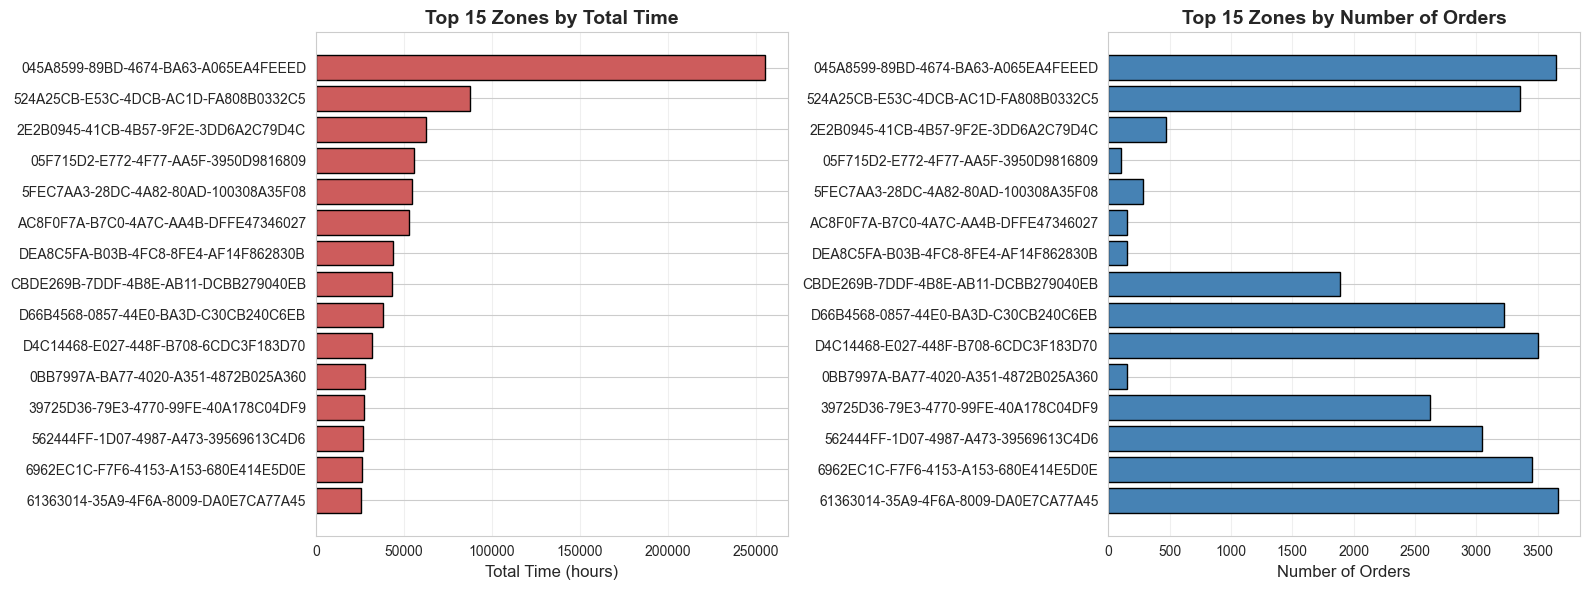

In [ ]:
# Query 7.1: Statistics per zone
print("="*80)
print("QUERY 7.1: Zone-by-Zone Performance Analysis")
print("="*80)

# Aggregate by zone
zone_analysis = df_timeregistrations.groupby('ZoneID').agg({
    'ProductionOrderID': 'nunique',
    'DurationSeconds': ['count', 'sum', 'mean', 'median', 'std']
}).reset_index()

zone_analysis.columns = ['ZoneID', 'NumOrders', 'NumSteps', 'TotalTime', 
                         'AvgStepTime', 'MedianStepTime', 'StdDevStepTime']

# Sort by total time
zone_analysis = zone_analysis.sort_values('TotalTime', ascending=False)

print("Top 15 Most Time-Consuming Zones:")
print(zone_analysis.head(15).to_string(index=False))

# Visualise top zones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top_zones = zone_analysis.head(15)

# Total time
ax1.barh(range(len(top_zones)), top_zones['TotalTime']/3600, color='indianred', edgecolor='black')
ax1.set_yticks(range(len(top_zones)))
ax1.set_yticklabels(top_zones['ZoneID'])
ax1.set_xlabel('Total Time (hours)', fontsize=12)
ax1.set_title('Top 15 Zones by Total Time', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Number of orders
ax2.barh(range(len(top_zones)), top_zones['NumOrders'], color='steelblue', edgecolor='black')
ax2.set_yticks(range(len(top_zones)))
ax2.set_yticklabels(top_zones['ZoneID'])
ax2.set_xlabel('Number of Orders', fontsize=12)
ax2.set_title('Top 15 Zones by Number of Orders', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# Query 7.3: Zones with highest data quality issues (short durations)
print("\n" + "="*80)
print("QUERY 7.3: Zones with Most Click-Through Behaviour")
print("="*80)

df_timeregistrations['IsShort'] = df_timeregistrations['DurationSeconds'] < 5

zone_quality = df_timeregistrations.groupby('ZoneID').agg({
    'DurationSeconds': 'count',
    'IsShort': 'sum'
}).reset_index()

zone_quality.columns = ['ZoneID', 'TotalSteps', 'StepsLT5Sec']
zone_quality['PctLT5Sec'] = (zone_quality['StepsLT5Sec'] / zone_quality['TotalSteps'] * 100).round(2)
zone_quality = zone_quality.sort_values('PctLT5Sec', ascending=False)

print("Top 15 Zones with Highest Click-Through % (<5 sec):")
print(zone_quality.head(15).to_string(index=False))

print()
print(f"⚠️  {len(zone_quality[zone_quality['PctLT5Sec'] > 90])} zones have >90% of steps <5 seconds")
print(f"⚠️  Click-through behaviour affects virtually all zones")


QUERY 7.3: Zones with Most Click-Through Behaviour
Top 15 Zones with Highest Click-Through % (<5 sec):
                              ZoneID  TotalSteps  StepsLT5Sec  PctLT5Sec
4BE4D4FB-9D48-4C59-A44B-25CD523BD1E6        3059         3018      98.66
5525BD98-84ED-4872-8809-D4AEB1DAD4A1        7976         7455      93.47
2E2B0945-41CB-4B57-9F2E-3DD6A2C79D4C      184924       170534      92.22
66C135A3-5159-491E-831F-D535EF1A2F56       78500        72201      91.98
0405A71E-0E02-466E-B8F1-8F110CB301E1       10412         9489      91.14
C37E1E06-2723-4C90-8440-D64ED4020727      306817       278408      90.74
94B4C2EB-8D25-47BD-B510-0A1CC1FB395F       18309        16576      90.53
33062873-D0CE-45BC-9AF2-DBE65C6A82C7        2531         2287      90.36
E0F60F06-FD64-4290-9065-FA2DA4C1203F       16839        15186      90.18
0DCA2C7D-E76E-4AE9-9EF7-F3646D0DB5A7      114157       102882      90.12
9AC3874D-66D2-4967-BF04-3896309EBF76       40580        36496      89.94
3AEBE3CB-72CA-4991-B

## 9. Section 8: Total Assembly Time per Production Order

### 9.1. Aggregating Total Assembly Time
Summing all zone durations per production order to estimate total build time.

In [ ]:
# Query 8.1: Total assembly time per production order
print("="*80)
print("QUERY 8.1: Total Assembly Time per Order")
print("="*80)

# Aggregate zone durations to order level
df_order_level = df_zone_level.groupby('ProductionOrderID').agg({
    'TotalZoneDuration': 'sum',
    'ZoneID': 'count'
}).reset_index()

df_order_level.columns = ['ProductionOrderID', 'TotalAssemblyTime', 'NumZones']

print(f"Total production orders: {len(df_order_level):,}")
print(f"Average zones per order: {df_order_level['NumZones'].mean():.1f}")
print()
print(df_order_level.head(10).to_string(index=False))

QUERY 8.1: Total Assembly Time per Order
Total production orders: 10,287
Average zones per order: 27.6

ProductionOrderID  TotalAssemblyTime  NumZones
                                   0         1
         B.04716.                  0         1
         B.15311.                  0         1
       PO00000001              35628         1
       PO00242569              16768        31
       PO00242571             140806        78
       PO00242576             187348        77
       PO00242577             125227        84
       PO00286143                  2         1
       PO00291884               2157         1



QUERY 8.2: Total Assembly Time Distribution
            Statistic        Value
         Total orders 1.028700e+04
  Mean duration (sec) 4.990714e+05
Median duration (sec) 5.580000e+03
        Std dev (sec) 5.994323e+06
   Min duration (sec) 0.000000e+00
   Max duration (sec) 3.356421e+08
            P25 (sec) 1.380000e+03
            P75 (sec) 1.485735e+05
            P95 (sec) 7.280887e+05


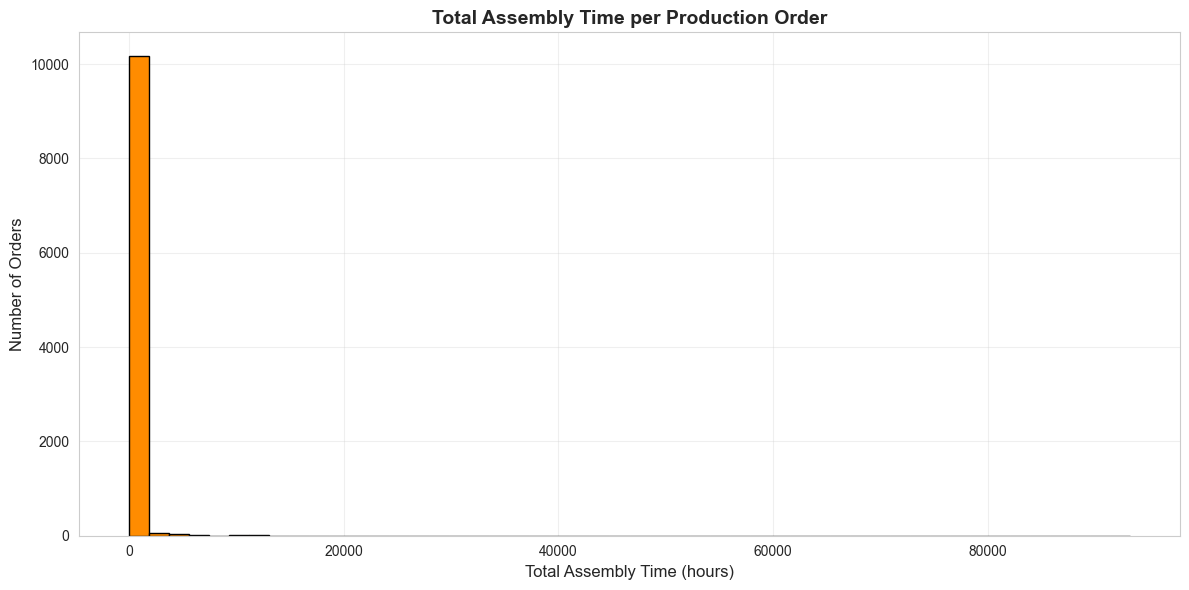


✅ Median total assembly time: 1.6 hours
✅ 95th percentile: 202.2 hours


In [ ]:
# Query 8.2: Distribution of total assembly times
print("\n" + "="*80)
print("QUERY 8.2: Total Assembly Time Distribution")
print("="*80)

order_durations = df_order_level['TotalAssemblyTime']

order_stats = pd.DataFrame({
    'Statistic': ['Total orders', 'Mean duration (sec)', 'Median duration (sec)',
                  'Std dev (sec)', 'Min duration (sec)', 'Max duration (sec)',
                  'P25 (sec)', 'P75 (sec)', 'P95 (sec)'],
    'Value': [
        len(order_durations),
        order_durations.mean(),
        order_durations.median(),
        order_durations.std(),
        order_durations.min(),
        order_durations.max(),
        order_durations.quantile(0.25),
        order_durations.quantile(0.75),
        order_durations.quantile(0.95)
    ]
})

print(order_stats.to_string(index=False))

# Visualise histogram
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(order_durations / 3600, bins=50, color='darkorange', edgecolor='black')
ax.set_title('Total Assembly Time per Production Order', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Assembly Time (hours)', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print()
print(f"✅ Median total assembly time: {order_durations.median()/3600:.1f} hours")
print(f"✅ 95th percentile: {order_durations.quantile(0.95)/3600:.1f} hours")

## 10. Summary and Conclusions

### Key Findings

- Step-level data is heavily skewed by click-through behaviour:
  - 79% of steps are under 5 seconds
  - Median step duration = 1 second
  - 7% of steps overlap in time
  - Many steps exceed 1 day, indicating forgotten timers

- Zone-level aggregation provides a more reliable signal:
  - Median zone duration = 12 minutes
  - Only 3% of zones are under 1 minute
  - Zone-level durations follow a more realistic distribution

- Total assembly time per production order:
  - Median = 5.6 hours
  - 95th percentile = 13.7 hours

### Recommendation

✅ Proceed with zone-level aggregation as the basis for predictive modelling  
⚠️ Avoid using raw step-level durations due to pervasive data quality issues  
📌 Consider filtering out durations <5s and >1 day to improve model robustnessm

---
## 11. Article-Level Analysis

This section mirrors the analysis in `ArticleAggregation.xlsx`. Instead of aggregating
step durations at the **zone level**, we now aggregate them at the **article level** by
joining `dbo.ninea_timeregistrations` with `dbo.ninea_assemblystep` on `assemblystepid`.

The two source SQL queries are:

- **Query 1** – Total duration per `(ArticleNumber, ProductionOrderNumber)` pair
  (one row per completed production order for a given article).
- **Query 2** – Mean duration per `ArticleNumber`, based on those completed orders,
  along with the number of production orders per article.

We reproduce both queries and then compute the same **Duration Analysis** summary
(overall statistics + distribution of per-article average duration into buckets)
that appears in the Excel workbook.

### 11.1. Query 1 – Total Duration per Production Order and Article

Joins `ninea_timeregistrations` with `ninea_assemblystep` to attach `articlenumber`
to each step, then sums step durations to obtain one `TotalDurationSeconds` value
per `(ArticleNumber, ProductionOrderNumber)` pair.

In [ ]:
# Query 1: Load article-level base data once and derive aggregates in pandas
print("="*80)
print("QUERY (Article Level): Load step-level article data")
print("="*80)

query_article_base = """
SELECT
    tr.productionordernumber AS ProductionOrderNumber,
    tr.zoneid AS ZoneID,
    tr.assemblystepid AS StepID,
    tr.startdate AS StartTime,
    tr.enddate AS EndTime,
    DATEDIFF(SECOND, tr.startdate, tr.enddate) AS DurationSeconds,
    st.articlenumber AS ArticleNumber
FROM dbo.ninea_timeregistrations AS tr
LEFT JOIN dbo.ninea_assemblystep AS st
    ON tr.assemblystepid = st.assemblystepid
WHERE tr.productionordernumber IS NOT NULL
  AND tr.startdate IS NOT NULL
  AND tr.enddate IS NOT NULL
  AND tr.enddate >= tr.startdate
  AND st.articlenumber IS NOT NULL
"""

df_article_base = pd.read_sql(query_article_base, conn)



QUERY (Article Level): Load step-level article data
✅ Loaded 6,436,420 step rows into a single DataFrame
   Distinct articles:          3,861
   Distinct production orders: 9,197
   Aggregated production-order rows: 165,286



,ArticleNumber,ProductionOrderNumber,TotalDurationSeconds
0,1031160F,PO00381953,2667
1,1031160F,PO00383431,38991
2,1031160F,PO00383846,1878
3,1031160F,PO00384198,4588
4,1031160F,PO00386522,0
5,1031160F,PO00387243,7575
6,1031160F,PO00387871,8907
7,1031160F,PO00388304,0
8,1031160F,PO00391211,4086
9,1031160F,PO00391714,4127


In [ ]:

# Clean and prepare the shared step-level DataFrame
if not df_article_base.empty:
    df_article_base = df_article_base.dropna(
        subset=["ProductionOrderNumber", "ArticleNumber", "DurationSeconds"]
    ).copy()
    df_article_base["DurationSeconds"] = pd.to_numeric(df_article_base["DurationSeconds"], errors="coerce")
    df_article_base = df_article_base.dropna(subset=["DurationSeconds"]).copy()

# Aggregate to one row per (ArticleNumber, ProductionOrderNumber)
df_article_po = (
    df_article_base.groupby(["ArticleNumber", "ProductionOrderNumber"], as_index=False)
    .agg(TotalDurationSeconds=("DurationSeconds", "sum"))
    .sort_values(["ArticleNumber", "ProductionOrderNumber"])
)

# Create the shared article-level summary DataFrame for downstream cells
article_summary = (
    df_article_po.groupby("ArticleNumber", as_index=False)
    .agg(
        MeanDurationSeconds=("TotalDurationSeconds", "mean"),
        NumberOfProductionOrders=("TotalDurationSeconds", "size"),
    )
    .sort_values("ArticleNumber")
)

print(f"✅ Loaded {len(df_article_base):,} step rows into a single DataFrame")
print(f"   Distinct articles:          {df_article_base['ArticleNumber'].nunique():,}")
print(f"   Distinct production orders: {df_article_base['ProductionOrderNumber'].nunique():,}")
print(f"   Aggregated production-order rows: {len(df_article_po):,}")
print()

# Add duration in hours for easier interpretation
df_article_po['TotalDurationHours'] = df_article_po['TotalDurationSeconds'] / 3600
#df_article_po.head(10)
df_article_po[df_article_po['ArticleNumber'] == 'G55108005000650']



✅ Loaded 6,436,420 step rows into a single DataFrame
   Distinct articles:          3,861
   Distinct production orders: 9,197
   Aggregated production-order rows: 165,286



,ArticleNumber,ProductionOrderNumber,TotalDurationSeconds
137882,G55108005000650,PO00368280,3941225
137883,G55108005000650,PO00368747,7592
137884,G55108005000650,PO00369021,11980
137885,G55108005000650,PO00380621,619138
137886,G55108005000650,PO00383459,12425
137887,G55108005000650,PO00388472,11760
137888,G55108005000650,PO00388475,11760
137889,G55108005000650,PO00396737,9895
137890,G55108005000650,PO00401616,6870
137891,G55108005000650,PO00401998,901


### 11.2. Overall Summary

Descriptive statistics computed directly from the row-level Query 1 output
(one row per production order for an article). This mirrors the top-left
summary block in the *Duration Analysis* sheet of `ArticleAggregation.xlsx`.

In [ ]:
# Overall summary from raw Query 1 data
print("="*80)
print("QUERY 1 SUMMARY: Overall Statistics (per Production Order)")
print("="*80)

po_durations = df_article_po['TotalDurationSeconds'].astype(float)

overall_summary = pd.DataFrame({
    'Metric': [
        'Total production orders',
        'Distinct article numbers',
        'Orders with zero duration',
        'Min duration (sec)',
        'Max duration (sec)',
        'Average duration (sec)',
        'Median duration (sec)',
        'Std dev of duration (sec)'
    ],
    'Value': [
        len(df_article_po),
        df_article_po['ArticleNumber'].nunique(),
        int((po_durations == 0).sum()),
        po_durations.min(),
        po_durations.max(),
        po_durations.mean(),
        po_durations.median(),
        po_durations.std()
    ]
})

print(overall_summary.to_string(index=False))

print()
print(f"💡 Distribution is right-skewed: median ({po_durations.median():,.0f}s) "
      f"<< mean ({po_durations.mean():,.0f}s)")
print(f"💡 A few very long orders (max = {po_durations.max():,.0f}s ≈ "
      f"{po_durations.max()/86400:,.1f} days) pull the mean up strongly")


QUERY 1 SUMMARY: Overall Statistics (per Production Order)
                   Metric        Value
  Total production orders 1.652860e+05
 Distinct article numbers 3.861000e+03
Orders with zero duration 1.732500e+04
       Min duration (sec) 0.000000e+00
       Max duration (sec) 2.176139e+08
   Average duration (sec) 3.036177e+04
    Median duration (sec) 4.330000e+02
Std dev of duration (sec) 8.345677e+05

💡 Distribution is right-skewed: median (433s) << mean (30,362s)
💡 A few very long orders (max = 217,613,945s ≈ 2,518.7 days) pull the mean up strongly


### 11.3. Query 2 – Mean Duration per Article

For each `ArticleNumber`, compute the **mean total-duration** across its completed
production orders, together with the count of orders. This is the per-article
pivot shown on the right-hand side of the *Duration Analysis* sheet.

In [ ]:
# Query 2: Mean duration per Article
print("="*80)
print("QUERY 2 (Article Level): Mean Duration per Article")
print("="*80)

query_article_mean = """
WITH ValidStepDurations AS
(
    SELECT
        st.articlenumber                                       AS ArticleNumber,
        tr.productionordernumber                               AS ProductionOrderNumber,
        CAST(DATEDIFF(SECOND, tr.startdate, tr.enddate) AS BIGINT) AS StepDurationSeconds
    FROM dbo.ninea_timeregistrations AS tr
    INNER JOIN dbo.ninea_assemblystep AS st
        ON tr.assemblystepid = st.assemblystepid
    WHERE tr.productionordernumber IS NOT NULL
      AND tr.startdate IS NOT NULL
      AND tr.enddate   IS NOT NULL
      AND tr.enddate   >= tr.startdate
      AND st.articlenumber IS NOT NULL
),
ProductionOrderDurations AS
(
    SELECT
        ArticleNumber,
        ProductionOrderNumber,
        SUM(StepDurationSeconds) AS TotalDurationSeconds
    FROM ValidStepDurations
    GROUP BY ArticleNumber, ProductionOrderNumber
)
SELECT
    ArticleNumber,
    AVG(CAST(TotalDurationSeconds AS DECIMAL(18,2))) AS MeanDurationSeconds,
    COUNT(*)                                        AS NumberOfProductionOrders
FROM ProductionOrderDurations
GROUP BY ArticleNumber
ORDER BY ArticleNumber;
"""

df_article_mean = pd.read_sql(query_article_mean, conn)
df_article_mean['MeanDurationSeconds'] = df_article_mean['MeanDurationSeconds'].astype(float)

print(f"✅ Loaded {len(df_article_mean):,} distinct articles")
print(f"   Total production orders covered: "
      f"{int(df_article_mean['NumberOfProductionOrders'].sum()):,}")
print()
df_article_mean.head(10)


QUERY 2 (Article Level): Mean Duration per Article


✅ Loaded 3,859 distinct articles
   Total production orders covered: 165,271



,ArticleNumber,MeanDurationSeconds,NumberOfProductionOrders
2852,G55108005000650,463354.6,10


### 11.4. Per-Article Aggregation Table

Recompute the per-article pivot directly in pandas from the Query 1 result, so we
have all standard statistics (`Order Count`, `Total`, `Avg`, `Min`, `Max`) in one
table. This is what feeds the distribution histogram in the next step.

In [ ]:
# Per-article pivot table (mirrors PivotTable in Duration Analysis sheet)
print("="*80)
print("Per-Article Aggregation")
print("="*80)

article_agg = df_article_po.groupby('ArticleNumber')['TotalDurationSeconds'].agg(
    OrderCount='count',
    TotalDuration='sum',
    AvgDuration='mean',
    MinDuration='min',
    MaxDuration='max'
).reset_index()

# Cross-check against Query 2 result
merged = article_agg.merge(
    df_article_mean, on='ArticleNumber', how='outer', suffixes=('', '_q2')
)
diff = (merged['AvgDuration'] - merged['MeanDurationSeconds']).abs().max()
print(f"Articles in pivot:              {len(article_agg):,}")
print(f"Max |AvgDuration - Query2Mean|: {diff:.6f}  (should be ~0)")
print()
article_agg.sample(20)


Per-Article Aggregation
Articles in pivot:              3,861
Max |AvgDuration - Query2Mean|: 12869.025000  (should be ~0)



,ArticleNumber,OrderCount,TotalDuration,AvgDuration,MinDuration,MaxDuration
2853,G55108005000650,10,4633546,463354.6,901,3941225


### 11.5. Distribution of Per-Article Average Duration

Bucket the per-article **average** duration, and visualise the resulting
histogram of articles per bucket.

Distribution of Per-Article AVERAGE Duration
Bucket (Avg duration)  Upper bound (sec)  Article count  Percentage (%)
            0 – 1 min               60.0            427           11.06
            1 – 5 min              300.0            450           11.66
           5 – 10 min              600.0            384            9.95
          10 – 30 min             1800.0            777           20.12
          30 – 60 min             3600.0            557           14.43
          1 – 2 hours             7200.0            450           11.66
         2 – 24 hours            86400.0            603           15.62
           > 24 hours                inf            213            5.52


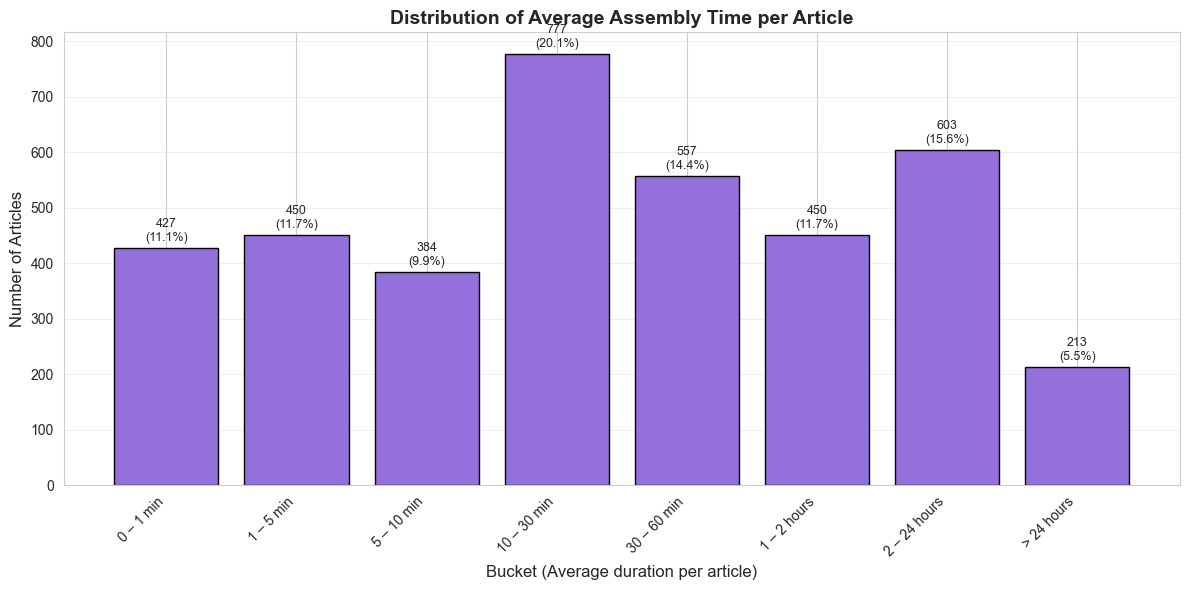


✅ 3,861 articles bucketed
✅ Most-populated bucket: 10 – 30 min (777 articles)


In [ ]:
# Distribution of per-article AVERAGE duration
print("="*80)
print("Distribution of Per-Article AVERAGE Duration")
print("="*80)

article_bins   = [0, 60, 300, 600, 1800, 3600, 7200, 86400, float('inf')]
article_labels = ['0 – 1 min', '1 – 5 min', '5 – 10 min', '10 – 30 min',
                  '30 – 60 min', '1 – 2 hours', '2 – 24 hours', '> 24 hours']

article_buckets = pd.cut(article_agg['AvgDuration'],
                         bins=article_bins, labels=article_labels,
                         include_lowest=True, right=True)
article_dist = article_buckets.value_counts().sort_index()
article_pct  = (article_dist / len(article_agg) * 100).round(2)

distribution_df = pd.DataFrame({
    'Bucket (Avg duration)': article_dist.index,
    'Upper bound (sec)':     article_bins[1:],
    'Article count':         article_dist.values,
    'Percentage (%)':        article_pct.values
})

print(distribution_df.to_string(index=False))

# Visualise
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(article_dist)), article_dist.values,
       color='mediumpurple', edgecolor='black')
ax.set_title('Distribution of Average Assembly Time per Article',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Bucket (Average duration per article)', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_xticks(range(len(article_dist)))
ax.set_xticklabels(article_labels, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
for i, (v, p) in enumerate(zip(article_dist.values, article_pct.values)):
    ax.text(i, v + max(article_dist.values)*0.01,
            f'{v:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print()
print(f"✅ {len(article_agg):,} articles bucketed")
print(f"✅ Most-populated bucket: "
      f"{article_dist.idxmax()} ({article_dist.max():,} articles)")
